# Exploring Raw Datasets before Processing 

### Import Libraries 

In [8]:
### Core python libs 
import os
import glob
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Data Science Tools 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### PySpark 
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

### Custom scripts from utils folder 
from utils.data_processing_bronze_table import process_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table_v2


In [9]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Data Exploration") \
    .getOrCreate()


25/06/21 17:08:29 WARN Utils: Your hostname, Xiao-Juns-Macbook-Pro-2.local resolves to a loopback address: 127.0.0.1; using 192.168.0.2 instead (on interface en0)
25/06/21 17:08:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/21 17:08:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Inspect the Bronze CSV files created for data understanding/ cleaning/ processing 

To determine whether a dataset is a snapshot table (incremental, appended) or an overwrite table (replaced every load), you can analyze how the data is structured and updated over time using customer_ID and snapshot_date.

1. Snapshot Table (Incremental / Appended)

- Definition: New rows are added regularly (e.g., daily, weekly), capturing the state of data at different points in time.
- Example: A table showing customer attributes as of each month end.
- Structure:
    - Multiple rows per customer_ID, each with a different snapshot_date.
    - snapshot_date increases with each new batch.
- Join Logic:
    - Must join on both customer_ID and snapshot_date to get a precise match.
- Use Case:
    - Track changes over time (e.g., customer churn analysis, monthly balances).
    
2. Overwrite Table
- Definition: The table is fully replaced during each data load.
- Example: A daily updated table that always shows the most recent customer status.
- Structure:
    - Only one row per customer_ID.
    - No meaningful or consistent snapshot_date.
    - snapshot_date (if present) may be empty or identical for all rows.
- Join Logic:
    - Only join on customer_ID.
    - Cannot join on snapshot_date, as the table only contains the latest version.


| Feature          | Snapshot Table                | Overwrite Table               |
| ---------------- | ----------------------------- | ----------------------------- |
| Data Growth      | Appended over time            | Replaced every load           |
| `customer_ID`    | Appears multiple times        | Appears once                  |
| `snapshot_date`  | Different values per record   | Usually one or null           |
| Join keys        | `customer_ID + snapshot_date` | `customer_ID` only            |
| Historical data  | Retained                      | Lost each update              |
| Example use case | Trend analysis, time series   | Latest state, real-time views |

Summary of logic: 

| Condition                                                                                | Conclusion                              |
| ---------------------------------------------------------------------------------------- | --------------------------------------- |
| No `Customer_ID` column                                                                  | ❓ Cannot determine                      |
| `snapshot_date` column exists AND >50% of customers have >1 unique snapshot              | ✅ Snapshot Table                        |
| `snapshot_date` column exists AND ≤50% of customers have >1 unique snapshot              | ⚠️ Overwrite Table                      |
| No `snapshot_date` column, but >50% of customers have >1 row                             | ✅ Likely Snapshot Table                 |
| No `snapshot_date` column, and ≤50% of customers have only 1 row                         | ⚠️ Likely Overwrite Table               |
| `Customer_ID` or `snapshot_date` exists but all values are null or no valid combinations | ⚠️ Cannot determine (insufficient data) |





In [15]:
import os
import glob
import pandas as pd

# Define folder paths
bronze_clickstream_directory = "datamart/bronze/clickstream"
bronze_attributes_directory = "datamart/bronze/attributes"
bronze_financials_directory = "datamart/bronze/financials"
bronze_lms_directory = "datamart/bronze/lms"

# Get list of CSV files in each folder
bronze_clickstream_files_list = glob.glob(os.path.join(bronze_clickstream_directory, '*.csv'))
bronze_financials_files_list = glob.glob(os.path.join(bronze_financials_directory, '*.csv'))
bronze_attributes_files_list = glob.glob(os.path.join(bronze_attributes_directory, '*.csv'))
bronze_lms_files_list = glob.glob(os.path.join(bronze_lms_directory, '*.csv'))

# Read and concatenate CSVs into DataFrames
clickstream = pd.concat([pd.read_csv(file) for file in bronze_clickstream_files_list], ignore_index=True)
attributes = pd.concat([pd.read_csv(file) for file in bronze_attributes_files_list], ignore_index=True)
financials = pd.concat([pd.read_csv(file) for file in bronze_financials_files_list], ignore_index=True)
lms = pd.concat([pd.read_csv(file) for file in bronze_lms_files_list], ignore_index=True)

# Ensure all columns are shown in output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Snapshot/overwrite detection logic
def detect_table_type(df):
    cols_lower = [c.lower() for c in df.columns]
    cust_col = next((c for c in df.columns if c.lower() == 'customer_id'), None)
    date_col = next((c for c in df.columns if 'snapshot' in c.lower() or 'date' in c.lower()), None)

    if not cust_col:
        return "❓ Cannot determine (no Customer_ID column)"

    if date_col:
        subset = df[[cust_col, date_col]].dropna()
        if subset.empty:
            return "⚠️ Cannot determine (no non-null Customer_ID/date pairs)"
        # Count unique dates per customer
        per_customer = subset.groupby(cust_col)[date_col].nunique()
        multi_snapshot_customers = (per_customer > 1).sum()
        unique_customers = per_customer.shape[0]

        if unique_customers == 0:
            return "⚠️ Cannot determine (no valid Customer_IDs)"
        ratio = multi_snapshot_customers / unique_customers

        if ratio > 0.5:
            return f"✅ Snapshot Table (avg >1 snapshot per customer, {ratio:.2%} multi-snapshot)"
        else:
            return f"⚠️ Overwrite Table (most customers have single date, {ratio:.2%} multi-snapshot)"
    else:
        # No date column: fall back on whether customers have multiple rows
        counts = df[cust_col].value_counts()
        multi_rows = (counts > 1).sum()
        total_customers = len(counts)
        ratio = multi_rows / total_customers if total_customers > 0 else 0

        if ratio > 0.5:
            return f"✅ Snapshot Table (no date col, but {ratio:.2%} customers have multiple records)"
        else:
            return f"⚠️ Overwrite Table (no date col, and {ratio:.2%} customers have single records)"

# Analyze and preview each DataFrame
for name, df in [("LMS", lms), ("Financials", financials), ("Attributes", attributes), ("Clickstream", clickstream)]:
    print(f"\n--- {name} ---")
    print(f"Shape: {df.shape}")
    print("\nData types:")
    print(df.dtypes)
    print("\nPreview:")
    print(df.tail(5))

    # Check and print number of unique Customer_IDs
    cust_col = next((c for c in df.columns if c.lower() == 'customer_id'), None)
    if cust_col:
        num_unique_customers = df[cust_col].nunique()
        print(f"\n👤 Unique Customer_IDs: {num_unique_customers}")
    else:
        print("\n👤 Unique Customer_IDs: Cannot determine (no Customer_ID column)")

    table_type = detect_table_type(df)
    print(f"\n➡️ Table Type: {table_type}")




--- LMS ---
Shape: (104288, 11)

Data types:
loan_id             object
Customer_ID         object
loan_start_date     object
tenure               int64
installment_num      int64
loan_amt             int64
due_amt            float64
paid_amt           float64
overdue_amt        float64
balance            float64
snapshot_date       object
dtype: object

Preview:
                     loan_id Customer_ID loan_start_date  tenure  \
104283  CUS_0xfe4_2023_09_01   CUS_0xfe4      2023-09-01      10   
104284  CUS_0xfe5_2023_06_01   CUS_0xfe5      2023-06-01      10   
104285  CUS_0xfea_2023_10_01   CUS_0xfea      2023-10-01      10   
104286  CUS_0xffc_2024_01_01   CUS_0xffc      2024-01-01      10   
104287  CUS_0xffd_2024_03_01   CUS_0xffd      2024-03-01      10   

        installment_num  loan_amt  due_amt  paid_amt  overdue_amt  balance  \
104283                7     10000   1000.0    1000.0          0.0   3000.0   
104284               10     10000   1000.0    1000.0          0.0   

### Clickstream EDA 
- A clickstream is a record of a user's interactions with a website or app — essentially a log of clicks, taps, page views, scrolls, and other user actions, usually collected for analytics and behavioral insights.
- From the above inspection of the data rows, there are 20 features labeled fe_1 to fe_20. The positive and negative integers might be referring to page visited, action type (click, view, search, scroll, etc), number of sessions, duration on page/ event counts, etc.
- The presence of both positive and negative values suggests that:
    - They might be standardized (e.g. z-scores: mean = 0, std = 1)
    - They could represent differences (e.g. user deviation from average behavior)
    - Output from a transformation/embedding (e.g. PCA, autoencoders, etc) 
- Some clickstream values can be negative
  - Scroll depth (e.g. pixels scrolled) → Could be negative if improperly tracked or measured from bottom-up
  - Engagement scores or calculated metrics → Could be negative if they are z-scores or differences from baselines
- As such, we will not be dropping rows with negative values or capping them at zero. We will leave the values as-is.
- CustomerID: StringType()
- Snapshot_date: DateType()

#### [Updates] After Data Understanding & EDA 
Upon inspecting the histograms of all 20 features, we observed that they are approximately normally distributed, centered around zero, and symmetric. This suggests that the values have likely been preprocessed and standardized to have a mean of 0 and a standard deviation of 1. As such, no further transformation is required. Negative values are common and expected in standardized data, so we will retain them as is.

In [14]:
clickstream.dtypes


fe_1              int64
fe_2              int64
fe_3              int64
fe_4              int64
fe_5              int64
fe_6              int64
fe_7              int64
fe_8              int64
fe_9              int64
fe_10             int64
fe_11             int64
fe_12             int64
fe_13             int64
fe_14             int64
fe_15             int64
fe_16             int64
fe_17             int64
fe_18             int64
fe_19             int64
fe_20             int64
Customer_ID      object
snapshot_date    object
dtype: object

25/06/11 04:56:43 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 872236 ms exceeds timeout 120000 ms
25/06/11 04:56:43 WARN SparkContext: Killing executors is not supported by current scheduler.
25/06/11 04:56:51 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [4]:
# Check summary statistics for fe_1 to fe_20
clickstream.loc[:, 'fe_1':'fe_20'].describe()

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
count,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000,215376.000000
mean,101.414796,103.096195,104.333709,105.648503,106.996676,103.235922,107.070337,110.718724,114.406354,117.775797,99.615537,99.823680,100.420804,100.025801,99.600383,99.860834,100.129425,100.125139,100.341162,100.046259
std,99.833594,99.930002,100.599865,100.326065,100.693607,100.270388,100.323265,100.243698,100.186139,100.807686,100.335428,100.591175,100.881826,101.070371,101.145906,100.751876,101.298428,102.231587,102.666804,103.589358
min,-378.000000,-356.000000,-399.000000,-307.000000,-343.000000,-321.000000,-368.000000,-361.000000,-328.000000,-317.000000,-375.000000,-344.000000,-355.000000,-394.000000,-351.000000,-342.000000,-329.000000,-344.000000,-401.000000,-354.000000
25%,34.000000,36.000000,36.000000,38.000000,39.000000,36.000000,39.000000,43.000000,47.000000,50.000000,32.000000,32.000000,33.000000,32.000000,31.000000,32.000000,32.000000,31.000000,31.000000,30.000000
50%,102.000000,103.000000,104.000000,106.000000,107.000000,103.000000,107.000000,111.000000,115.000000,118.000000,100.000000,100.000000,101.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
75%,169.000000,171.000000,172.000000,173.000000,175.000000,171.000000,174.000000,179.000000,182.000000,186.000000,167.000000,168.000000,168.000000,168.000000,168.000000,168.000000,169.000000,169.000000,170.000000,170.000000
max,541.000000,560.000000,583.000000,562.000000,570.000000,565.000000,537.000000,573.000000,577.000000,537.000000,613.000000,550.000000,530.000000,583.000000,597.000000,554.000000,516.000000,551.000000,560.000000,547.000000


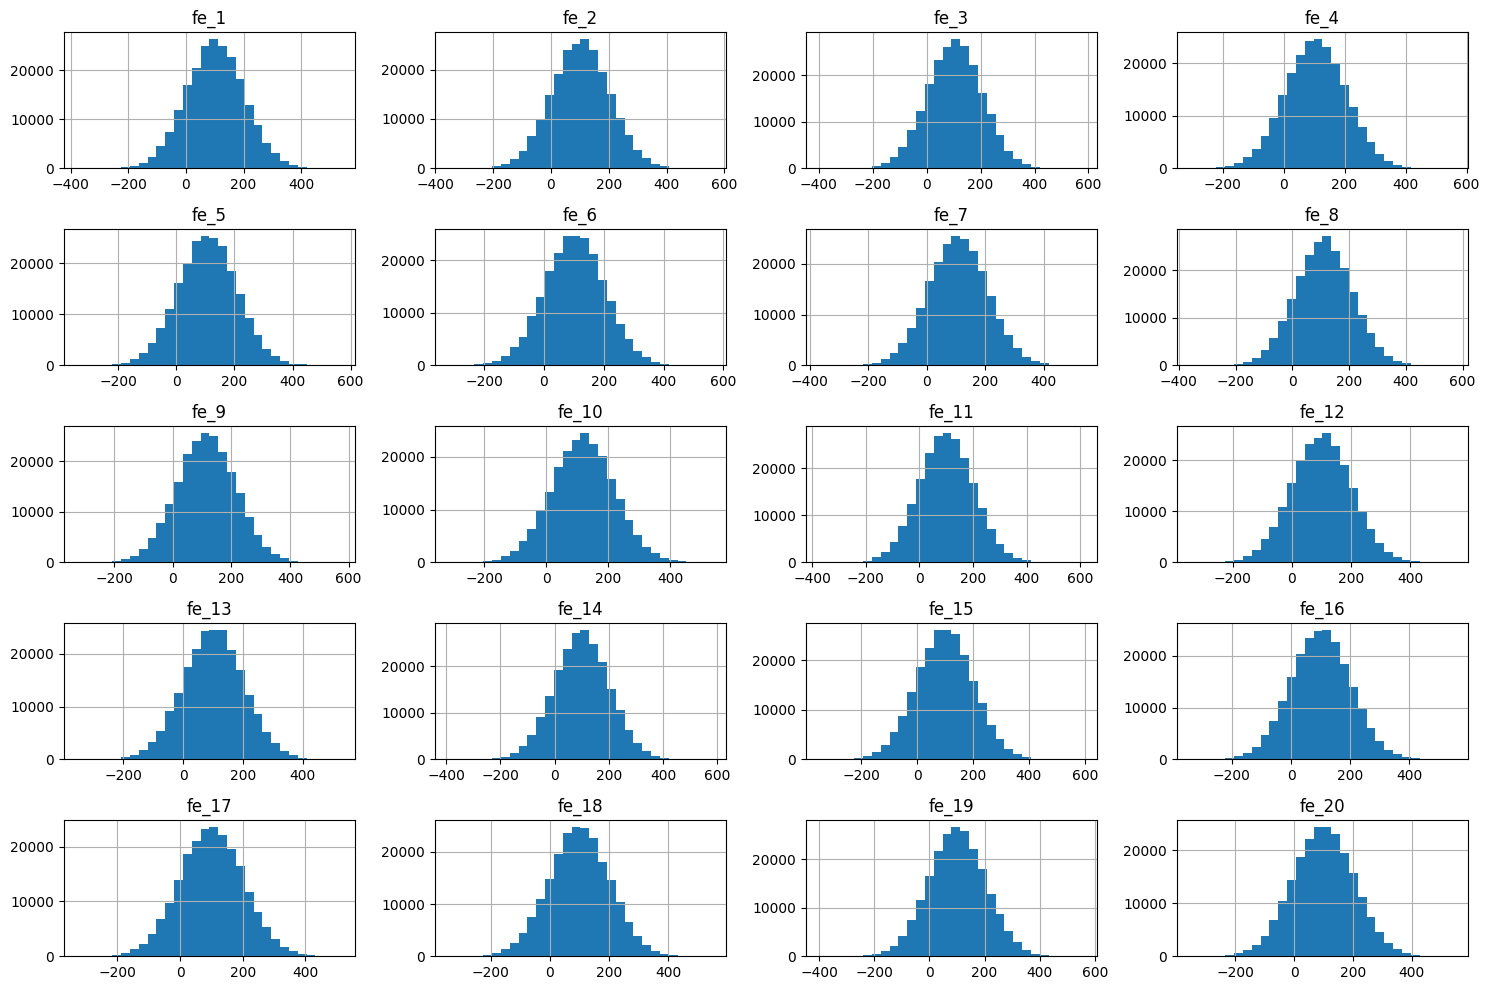

In [5]:
# Plot histograms for each feature
clickstream.loc[:, 'fe_1':'fe_20'].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()


In [6]:
# Count of negative values in each feature
neg_counts = (clickstream.loc[:, 'fe_1':'fe_20'] < 0).sum()
print("Negative value counts:\n", neg_counts)


Negative value counts:
 fe_1     33159
fe_2     32170
fe_3     32079
fe_4     31150
fe_5     30734
fe_6     32353
fe_7     30479
fe_8     28891
fe_9     27224
fe_10    25995
fe_11    34235
fe_12    34194
fe_13    34137
fe_14    34541
fe_15    34778
fe_16    34318
fe_17    34460
fe_18    34733
fe_19    34918
fe_20    35829
dtype: int64


In [8]:
# Count of null (NaN) values in each feature
null_counts = clickstream.loc[:, 'fe_1':'fe_20'].isnull().sum()
print("Null (NaN) value counts:\n", null_counts)


Null (NaN) value counts:
 fe_1     0
fe_2     0
fe_3     0
fe_4     0
fe_5     0
fe_6     0
fe_7     0
fe_8     0
fe_9     0
fe_10    0
fe_11    0
fe_12    0
fe_13    0
fe_14    0
fe_15    0
fe_16    0
fe_17    0
fe_18    0
fe_19    0
fe_20    0
dtype: int64


### Attributes EDA 
- CustomerID, Name: StringType()
- Snapshot_date: DateType() 
- Age: removed trailing underscores, flipped negative ages to positive
- Occupation: replaced _____ entries with None, removed underscore between "Media_Manager", lower cased everything
- SSN: replaced #F%$D@*&8 entries with None using regex to exclude them

#### [Updates] After Data Understanding & EDA 
Data understanding: Age contains many highly physiologically impossible values, we plotted histograms to visualize the distribution of ages and decided to keep the age range to be within 0 and 120 years old. Those ages that were out of range were subsequently converted into None. After cleaning up all the other columns and combining them to form the gold layer, we will then decide whether we should be dropping these values (if the number of rows is negligible compared to the entire dataset) or imputating mean/median (to be performed after train-test split to prevent data leakage). 

Name: Some entries are dirty with trailing ", but we will not be cleaning it up because it is a unique identifier, we will be dropping the entire column before model training.

In [10]:
attributes = pd.concat([pd.read_csv(file) for file in bronze_attributes_files_list], ignore_index=True)

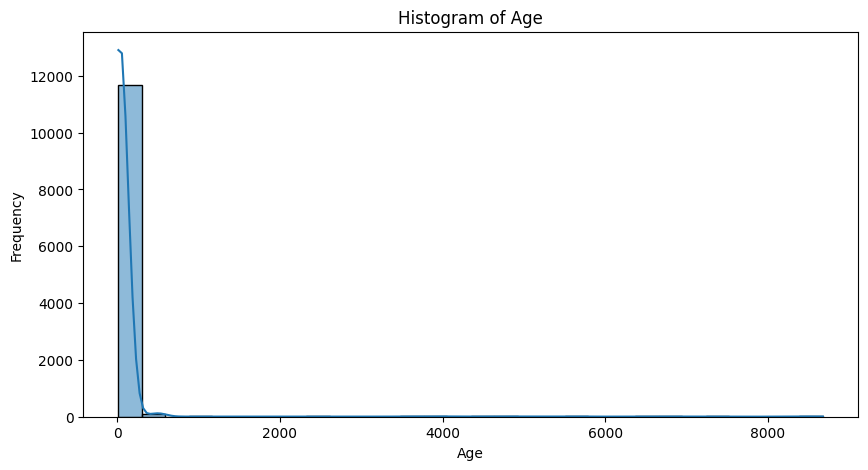

In [11]:
# Step 1: Clean Age column - remove underscores, convert to numeric, coerce errors to NaN
attributes['Age_clean'] = pd.to_numeric(attributes['Age'].astype(str).str.replace('_', ''), errors='coerce')

# Step 1.5: Flip negative ages to positive
attributes['Age_clean'] = attributes['Age_clean'].abs()

# Step 2: Plot histogram using cleaned and positive Age
plt.figure(figsize=(10, 5))
sns.histplot(attributes['Age_clean'].dropna(), bins=30, kde=True)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


In [12]:
count_above_120 = attributes[attributes['Age_clean'] > 120].shape[0]
print(f"Number of entries with Age > 120: {count_above_120}")


Number of entries with Age > 120: 304


In [13]:
# Define reasonable age bounds
min_age = 0
max_age = 120

# Filter out impossible ages
attributes = attributes[
    (attributes['Age_clean'] >= min_age) & (attributes['Age_clean'] <= max_age)
]

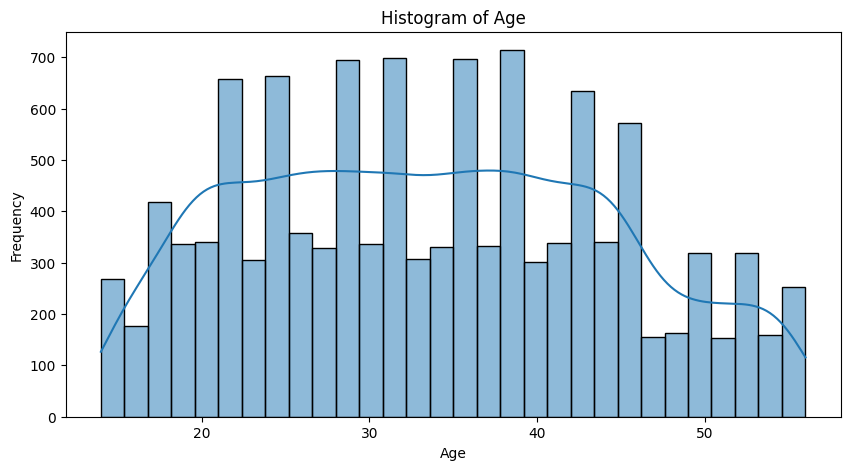

In [14]:
# Plot histogram after removing outliers
plt.figure(figsize=(10, 5))
sns.histplot(attributes['Age_clean'].dropna(), bins=30, kde=True)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [23]:
pd.set_option('display.max_rows', None)  # Show all rows
attributes['Name'].value_counts(dropna=False)


Name
Langep                       6
Stevex                       6
Vaughanl                     5
Raymondr                     5
Nate Raymondw                5
Caroline Valetkevitchj       5
Michaelr                     5
Jonesb                       5
Andreaj                      5
Huwk                         5
Kimj                         5
Jessica Wohlt                5
Strupczewskid                5
Davidc                       5
Valetkevitchv                5
Jonathan Stempelr            5
Phila                        5
Lucia Mutikanip              5
Phil Wahbag                  5
Jessicad                     5
Katharina Barty              4
Dhanya Skariachanh           4
Alexu                        4
Karenh                       4
Jessical                     4
Skariachanv                  4
Carolineg                    4
Oreskovicw                   4
Lauren Taraf                 4
Aruna Viswanathao            4
Jasonb                       4
Greg Roumeliotise            4
Nic

In [22]:
pd.set_option('display.max_rows', None)  # Show all rows
attributes['Occupation'].value_counts(dropna=False)


Occupation
_______          828
Lawyer           761
Architect        752
Accountant       749
Engineer         739
Teacher          737
Entrepreneur     731
Media_Manager    730
Scientist        727
Mechanic         724
Journalist       717
Developer        715
Doctor           709
Musician         695
Writer           679
Manager          677
Name: count, dtype: int64

In [24]:
pd.set_option('display.max_rows', None)  # Show all rows
attributes['SSN'].value_counts(dropna=False)


SSN
#F%$D@*&8      659
081-93-4350      1
035-83-1012      1
948-92-5850      1
747-79-7877      1
185-36-2802      1
092-76-3178      1
097-85-1090      1
344-73-9102      1
330-09-7564      1
316-92-2785      1
044-37-0803      1
136-39-0495      1
316-83-4105      1
990-15-5111      1
256-19-0938      1
899-16-9688      1
699-49-5543      1
512-27-0955      1
021-69-2391      1
887-23-0031      1
008-81-3367      1
109-01-0234      1
387-02-5364      1
743-66-3711      1
540-26-9440      1
222-08-8611      1
667-28-7573      1
446-78-2504      1
349-57-1872      1
925-98-6413      1
078-20-5154      1
063-94-6538      1
131-37-1161      1
178-96-0125      1
846-60-3664      1
212-98-0232      1
591-07-8373      1
460-15-2731      1
724-94-0404      1
502-34-9558      1
298-78-5836      1
840-30-6552      1
042-68-5885      1
563-29-1145      1
238-79-7321      1
552-70-4063      1
927-78-1000      1
214-58-4052      1
372-34-8477      1
879-63-4182      1
284-09-4067      1
705-82-0

### Financials EDA 

In [4]:
financials = pd.concat([pd.read_csv(file) for file in bronze_financials_files_list], ignore_index=True)


In [5]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Num_Bank_Accounts'].value_counts(dropna=False)


Num_Bank_Accounts
 6       1543
 8       1530
 7       1510
 4       1478
 5       1450
 3       1425
 9        663
 10       618
 1        549
 2        521
 0        519
-1          4
 11         3
 805        2
 560        2
 809        2
 1201       2
 933        2
 229        2
 609        1
 1605       1
 1364       1
 239        1
 565        1
 821        1
 313        1
 356        1
 882        1
 82         1
 1070       1
 1069       1
 203        1
 272        1
 1164       1
 1083       1
 275        1
 122        1
 850        1
 813        1
 983        1
 216        1
 1076       1
 1291       1
 980        1
 1530       1
 340        1
 514        1
 160        1
 57         1
 535        1
 888        1
 427        1
 1377       1
 832        1
 796        1
 627        1
 1213       1
 1240       1
 1075       1
 916        1
 1363       1
 701        1
 53         1
 794        1
 1169       1
 1277       1
 1564       1
 1122       1
 334        1
 161        1
 3

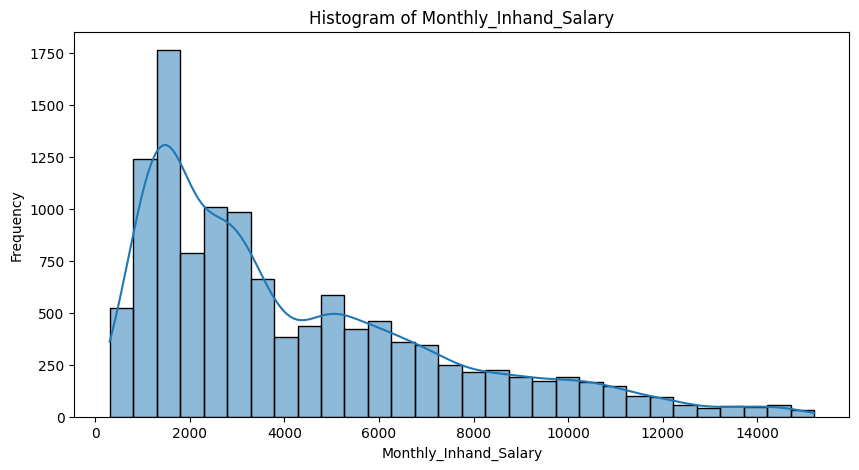

In [6]:
# Plot histogram for Monthly_Inhand_Salary
plt.figure(figsize=(10, 5))
sns.histplot(financials['Monthly_Inhand_Salary'].dropna(), bins=30, kde=True)
plt.title('Histogram of Monthly_Inhand_Salary')
plt.xlabel('Monthly_Inhand_Salary')
plt.ylabel('Frequency')
plt.show()


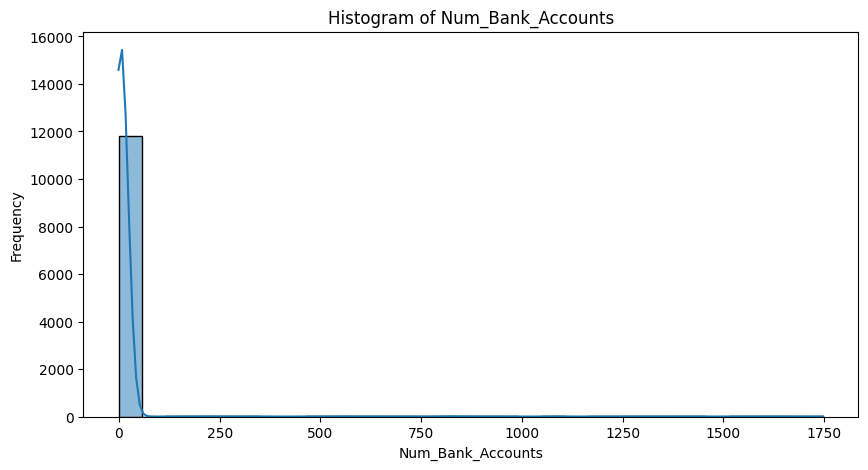

In [16]:
# Plot histogram for Num_Bank_Accounts
plt.figure(figsize=(10, 5))
sns.histplot(financials['Num_Bank_Accounts'].dropna(), bins=30, kde=True)
plt.title('Histogram of Num_Bank_Accounts')
plt.xlabel('Num_Bank_Accounts')
plt.ylabel('Frequency')
plt.show()


In [17]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Num_Bank_Accounts'].value_counts(dropna=False)


Num_Bank_Accounts
 6       1543
 8       1530
 7       1510
 4       1478
 5       1450
 3       1425
 9        663
 10       618
 1        549
 2        521
 0        519
-1          4
 11         3
 805        2
 560        2
 809        2
 1201       2
 933        2
 229        2
 609        1
 1605       1
 1364       1
 239        1
 565        1
 821        1
 313        1
 356        1
 882        1
 82         1
 1070       1
 1069       1
 203        1
 272        1
 1164       1
 1083       1
 275        1
 122        1
 850        1
 813        1
 983        1
 216        1
 1076       1
 1291       1
 980        1
 1530       1
 340        1
 514        1
 160        1
 57         1
 535        1
 888        1
 427        1
 1377       1
 832        1
 796        1
 627        1
 1213       1
 1240       1
 1075       1
 916        1
 1363       1
 701        1
 53         1
 794        1
 1169       1
 1277       1
 1564       1
 1122       1
 334        1
 161        1
 3

In [18]:
# Define reasonable num bounds
min = 0
max = 15

# Filter out impossible num
financials = financials[
    (financials['Num_Bank_Accounts'] >= min) & (financials['Num_Bank_Accounts'] <= max)
]

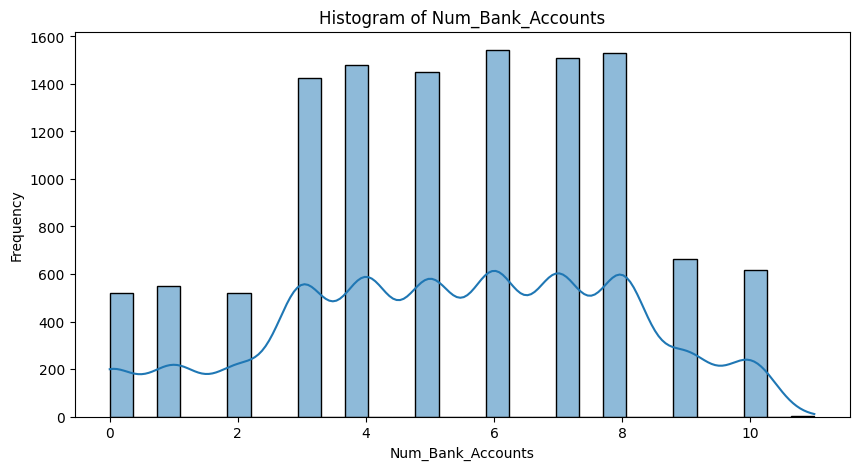

In [19]:
# Plot histogram after removing outliers
plt.figure(figsize=(10, 5))
sns.histplot(financials['Num_Bank_Accounts'].dropna(), bins=30, kde=True)
plt.title('Histogram of Num_Bank_Accounts')
plt.xlabel('Num_Bank_Accounts')
plt.ylabel('Frequency')
plt.show()

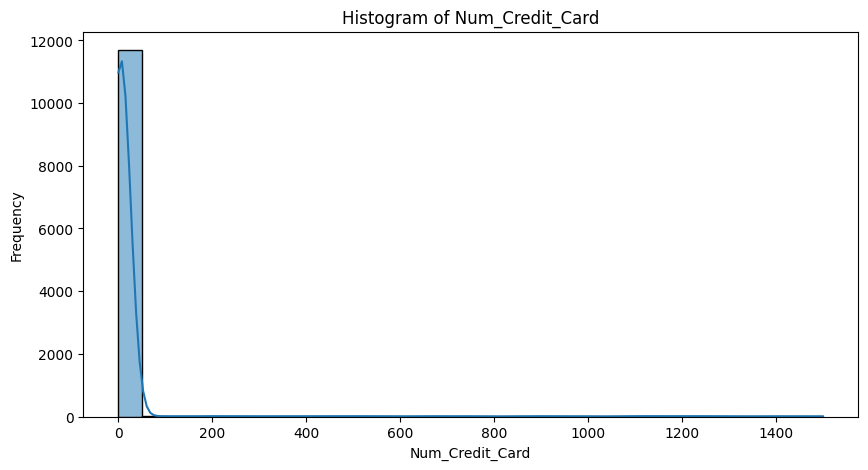

In [7]:
# Plot histogram for Num_Credit_Card
plt.figure(figsize=(10, 5))
sns.histplot(financials['Num_Credit_Card'].dropna(), bins=30, kde=True)
plt.title('Histogram of Num_Credit_Card')
plt.xlabel('Num_Credit_Card')
plt.ylabel('Frequency')
plt.show()


In [8]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Num_Credit_Card'].value_counts(dropna=False)

Num_Credit_Card
5       2211
7       2005
6       1959
4       1683
3       1573
10       588
8        581
9        565
2        266
1        247
11         8
0          4
180        3
399        3
662        2
958        2
470        2
1226       2
660        2
1123       2
680        2
25         2
988        2
1407       2
859        2
183        2
1180       2
1498       2
512        2
563        2
294        2
366        1
520        1
1281       1
238        1
1328       1
1246       1
501        1
100        1
888        1
929        1
879        1
194        1
192        1
1262       1
1413       1
1371       1
1029       1
1131       1
329        1
1467       1
253        1
1375       1
1452       1
992        1
726        1
1420       1
1374       1
1172       1
732        1
547        1
570        1
219        1
837        1
426        1
535        1
896        1
782        1
110        1
799        1
524        1
1072       1
516        1
1093       1
579        1
214      

In [37]:
# Define reasonable num bounds
min = 0
max = 15

# Filter out impossible num
financials = financials[
    (financials['Num_Credit_Card'] >= min) & (financials['Num_Credit_Card'] <= max)
]

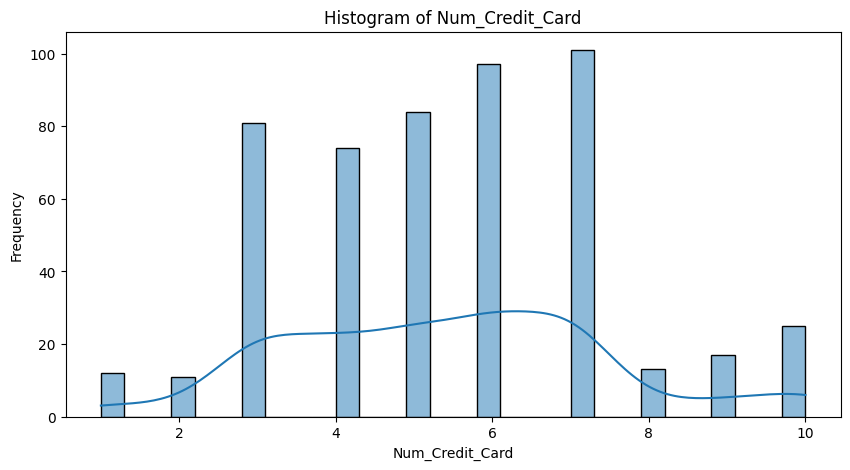

In [38]:
# Plot histogram after removing outliers
plt.figure(figsize=(10, 5))
sns.histplot(financials['Num_Credit_Card'].dropna(), bins=30, kde=True)
plt.title('Histogram of Num_Credit_Card')
plt.xlabel('Num_Credit_Card')
plt.ylabel('Frequency')
plt.show()

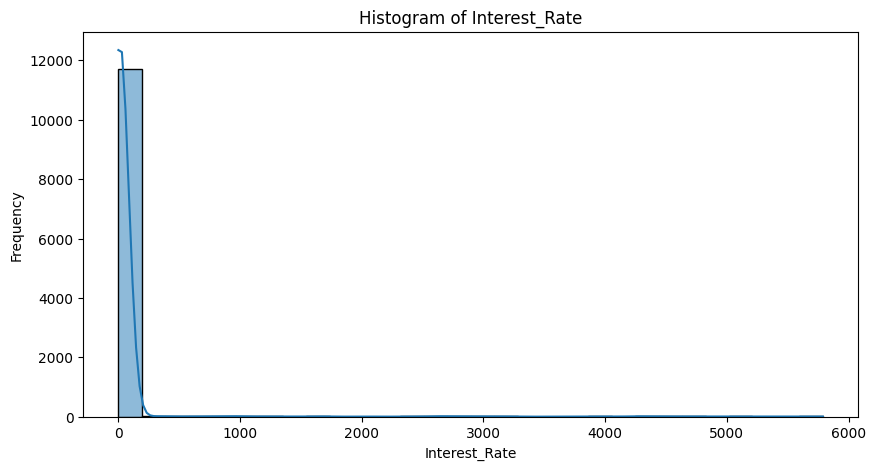

In [9]:
# Plot histogram for Interest_Rate
plt.figure(figsize=(10, 5))
sns.histplot(financials['Interest_Rate'].dropna(), bins=30, kde=True)
plt.title('Histogram of Interest_Rate')
plt.xlabel('Interest_Rate')
plt.ylabel('Frequency')
plt.show()

In [10]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Interest_Rate'].value_counts(dropna=False)

Interest_Rate
8       602
5       598
6       560
7       542
12      538
10      536
11      533
9       533
15      486
18      484
20      470
17      458
16      440
19      428
3       331
1       320
4       310
2       293
13      287
14      268
22      211
30      207
32      207
23      204
24      203
29      196
27      194
25      194
28      193
33      181
34      179
31      177
21      177
26      174
498       2
1292      2
981       1
1091      1
781       1
2061      1
348       1
5024      1
2660      1
3604      1
5272      1
4237      1
4257      1
3032      1
4759      1
2997      1
2127      1
3223      1
4376      1
1132      1
1655      1
1106      1
5114      1
1562      1
1615      1
1044      1
4578      1
917       1
4613      1
4800      1
3213      1
3887      1
279       1
3110      1
3647      1
1293      1
332       1
4446      1
2348      1
318       1
4651      1
328       1
106       1
5371      1
107       1
5663      1
2620      1
2828      1
47

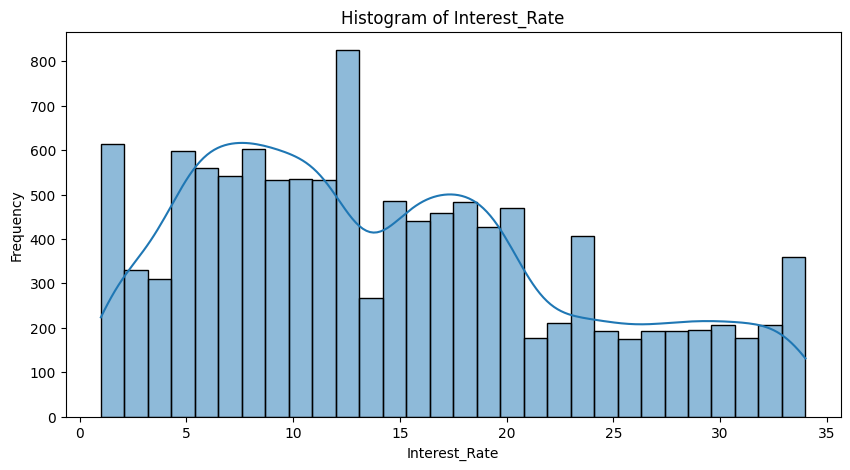

In [11]:
# Define reasonable num bounds
min = 0
max = 40

# Filter out impossible num
financials = financials[
    (financials['Interest_Rate'] >= min) & (financials['Interest_Rate'] <= max)]

# Plot histogram after removing outliers
plt.figure(figsize=(10, 5))
sns.histplot(financials['Interest_Rate'].dropna(), bins=30, kde=True)
plt.title('Histogram of Interest_Rate')
plt.xlabel('Interest_Rate')
plt.ylabel('Frequency')
plt.show()

In [15]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Num_of_Loan'].value_counts(dropna=False)

Num_of_Loan
3       1295
4       1222
2       1205
0       1103
1       1067
100      244
5        185
7        173
6        172
9         20
8         12
653        1
1070       1
172        1
18         1
1320       1
1430       1
1171       1
186        1
795        1
119        1
103        1
777        1
1478       1
1053       1
1393       1
463        1
27         1
966        1
65         1
614        1
420        1
699        1
1412       1
945        1
497        1
1159       1
438        1
87         1
781        1
227        1
439        1
1127       1
999        1
1074       1
31         1
365        1
799        1
332        1
1348       1
Name: count, dtype: int64

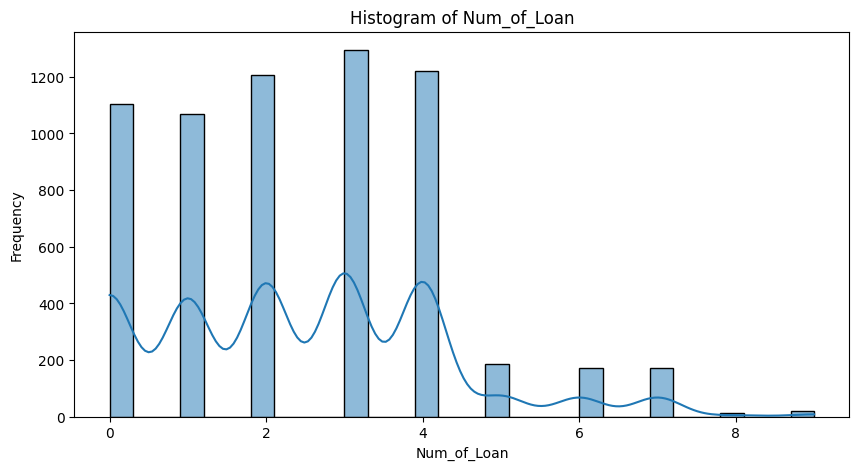

In [17]:
financials['Num_of_Loan'] = pd.to_numeric(financials['Num_of_Loan'].astype(str).str.replace('_', ''), errors='coerce')

financials['Num_of_Loan'] = financials['Num_of_Loan'].abs()

# Define reasonable num bounds
min = 0
max = 15

# Filter out impossible num
financials = financials[
    (financials['Num_of_Loan'] >= min) & (financials['Num_of_Loan'] <= max)]

# Step 2: Plot histogram using cleaned and positive 
plt.figure(figsize=(10, 5))
sns.histplot(financials['Num_of_Loan'].dropna(), bins=30, kde=True)
plt.title('Histogram of Num_of_Loan')
plt.xlabel('Num_of_Loan')
plt.ylabel('Frequency')
plt.show()


In [18]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Delay_from_due_date'].value_counts(dropna=False)

Delay_from_due_date
 13    331
 8     326
 14    321
 7     311
 9     301
 10    295
 15    293
 5     276
 6     276
 12    272
 11    270
 4     183
 3     171
 16    164
 18    160
 19    159
 27    159
 17    150
 28    147
 30    146
 1     145
 26    143
 20    143
 23    141
 29    141
 21    138
 2     135
 24    135
 0     132
 25    125
 22    122
 31     28
-1      27
 32     24
 33     16
-3      16
-2      15
-4      12
 35      7
 38      6
-5       5
 47      5
 37      5
 55      5
 53      5
 34      5
 40      4
 50      4
 52      4
 48      4
 60      4
 62      4
 44      3
 41      3
 39      3
 58      3
 54      3
 59      3
 45      3
 43      3
 49      2
 36      2
 56      2
 46      2
 42      2
 57      2
 51      1
 61      1
Name: count, dtype: int64

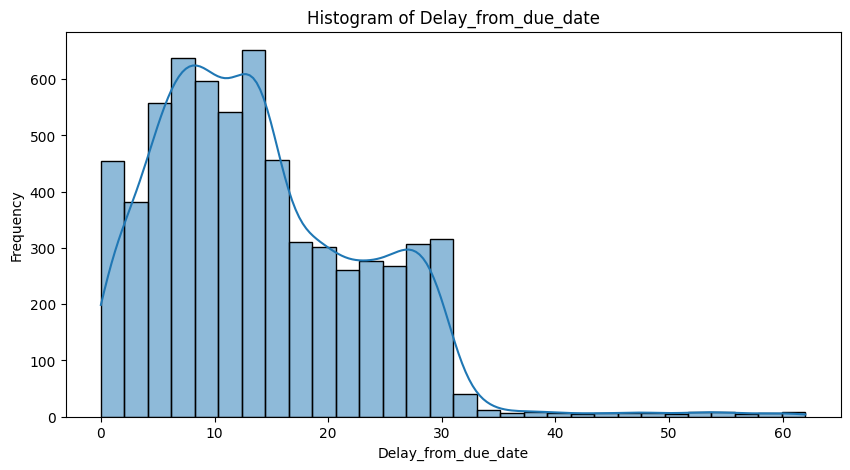

In [19]:
financials['Delay_from_due_date'] = financials['Delay_from_due_date'].abs()

# Step 2: Plot histogram using cleaned and positive 
plt.figure(figsize=(10, 5))
sns.histplot(financials['Delay_from_due_date'].dropna(), bins=30, kde=True)
plt.title('Histogram of Delay_from_due_date')
plt.xlabel('Delay_from_due_date')
plt.ylabel('Frequency')
plt.show()

In [20]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Num_of_Delayed_Payment'].value_counts(dropna=False)

Num_of_Delayed_Payment
10       461
8        459
9        427
12       409
11       406
13       280
7        277
15       271
14       268
6        260
16       255
17       243
20       240
19       237
5        228
2        226
18       224
3        224
4        200
1        193
0        187
21        58
-1        40
22        34
-2        25
23        20
9_        15
12_       14
8_        13
24        12
2_        12
11_       12
10_       12
15_       12
19_       11
13_       11
18_       10
14_       10
7_        10
6_         9
25         9
-3         9
16_        9
1_         8
20_        7
3_         6
17_        6
5_         6
4_         5
27         3
0_         3
26         3
-3_        2
3845       1
4106       1
430        1
2666       1
1263       1
1177       1
1841       1
4069       1
3827       1
-1_        1
2324       1
3881       1
1975       1
758_       1
1879       1
3533       1
2148       1
996        1
25_        1
2810       1
2222       1
133        1
18

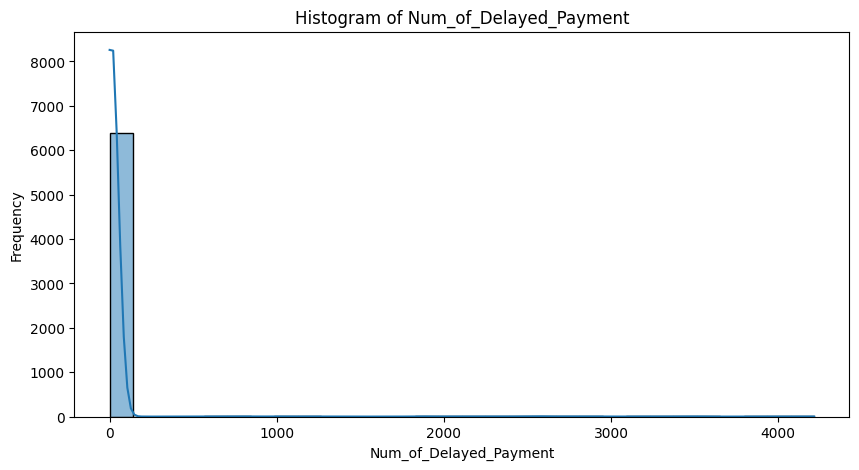

In [21]:
financials['Num_of_Delayed_Payment'] = pd.to_numeric(financials['Num_of_Delayed_Payment'].astype(str).str.replace('_', ''), errors='coerce')

financials['Num_of_Delayed_Payment'] = financials['Num_of_Delayed_Payment'].abs()

# Step 2: Plot histogram using cleaned and positive 
plt.figure(figsize=(10, 5))
sns.histplot(financials['Num_of_Delayed_Payment'].dropna(), bins=30, kde=True)
plt.title('Histogram of Num_of_Delayed_Payment')
plt.xlabel('Num_of_Delayed_Payment')
plt.ylabel('Frequency')
plt.show()


In [22]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Num_of_Delayed_Payment'].value_counts(dropna=False)

Num_of_Delayed_Payment
10      473
8       472
9       442
12      423
11      418
13      291
7       287
15      283
14      278
6       269
16      264
2       264
17      249
19      248
20      247
1       242
3       241
5       234
18      234
4       205
0       190
21       58
22       34
23       21
24       12
25       10
26        3
27        3
2324      1
3881      1
1263      1
4069      1
1879      1
1841      1
1177      1
4106      1
2666      1
430       1
1975      1
3827      1
2950      1
3533      1
758       1
2148      1
2810      1
2222      1
133       1
3260      1
2589      1
2697      1
3845      1
2943      1
3488      1
1850      1
996       1
3750      1
2072      1
2521      1
2560      1
3951      1
4216      1
1014      1
3155      1
1473      1
3316      1
938       1
2056      1
2590      1
834       1
787       1
2080      1
2801      1
2334      1
1820      1
2508      1
1154      1
2529      1
2503      1
733       1
3539      1
615       1
88   

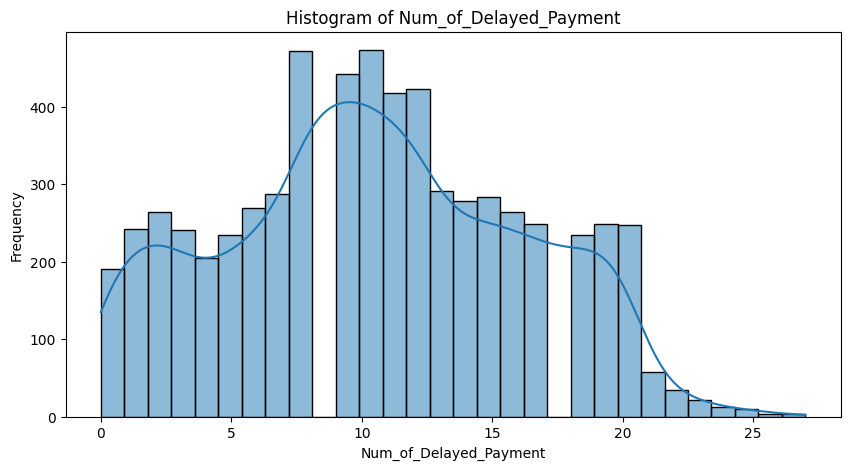

In [23]:
# Define reasonable num bounds
min = 0
max = 50

# Filter out impossible num
financials = financials[
    (financials['Num_of_Delayed_Payment'] >= min) & (financials['Num_of_Delayed_Payment'] <= max)]

# Plot histogram after removing outliers
plt.figure(figsize=(10, 5))
sns.histplot(financials['Num_of_Delayed_Payment'].dropna(), bins=30, kde=True)
plt.title('Histogram of Num_of_Delayed_Payment')
plt.xlabel('Num_of_Delayed_Payment')
plt.ylabel('Frequency')
plt.show()

In [24]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Changed_Credit_Limit'].value_counts(dropna=False)

Changed_Credit_Limit
_                        126
8.99                      13
11.73                     13
10.54                     12
10.46                     12
11.5                      12
10.39                     11
1.59                      11
3.93                      11
0.57                      11
7.01                      11
11.49                     11
5.5                       10
10.34                     10
7.64                      10
8.76                      10
11.63                     10
1.63                      10
7.69                      10
10.06                     10
8.24                       9
7.55                       9
8.23                       9
8.34                       9
5.08                       9
8.37                       9
9.2                        9
1.17                       9
9.66                       9
7.23                       9
11.9                       9
8.22                       9
8.42                       9
7.33                  

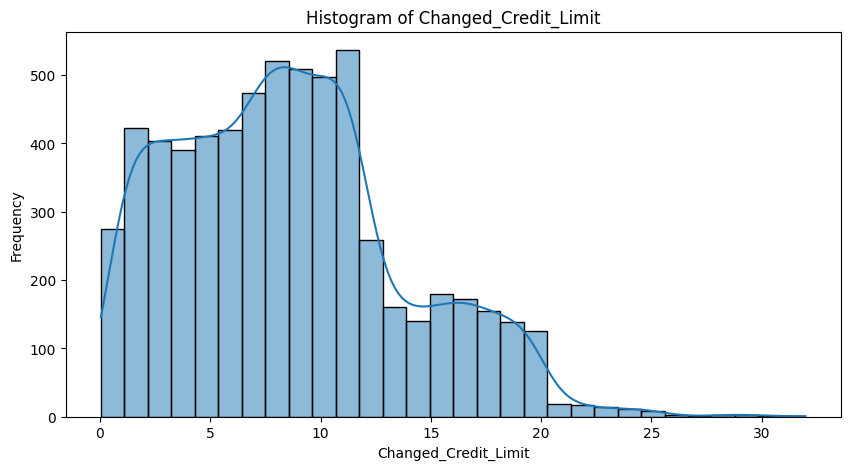

In [25]:
# Step 1: Clean Changed_Credit_Limit column
financials['Changed_Credit_Limit'] = pd.to_numeric(
    financials['Changed_Credit_Limit'].astype(str).str.replace('_', ''),
    errors='coerce'
)

# Step 2: Take absolute value to flip negatives
financials['Changed_Credit_Limit'] = financials['Changed_Credit_Limit'].abs()

# Step 3: Plot histogram using cleaned and positive values
plt.figure(figsize=(10, 5))
sns.histplot(financials['Changed_Credit_Limit'].dropna(), bins=30, kde=True)
plt.title('Histogram of Changed_Credit_Limit')
plt.xlabel('Changed_Credit_Limit')
plt.ylabel('Frequency')
plt.show()


In [26]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Num_Credit_Inquiries'].value_counts(dropna=False)

Num_Credit_Inquiries
4.0       948
3.0       804
5.0       718
2.0       666
6.0       620
1.0       526
7.0       519
8.0       418
0.0       404
9.0       268
10.0      140
11.0      116
12.0       80
13.0       38
14.0       10
15.0       10
16.0        6
17.0        5
1194.0      2
1497.0      1
1127.0      1
318.0       1
2407.0      1
1412.0      1
2342.0      1
66.0        1
1423.0      1
1726.0      1
1834.0      1
1307.0      1
1375.0      1
2043.0      1
1050.0      1
262.0       1
1339.0      1
446.0       1
777.0       1
2018.0      1
31.0        1
1543.0      1
159.0       1
1146.0      1
1967.0      1
876.0       1
309.0       1
2331.0      1
881.0       1
1213.0      1
2554.0      1
1136.0      1
1086.0      1
762.0       1
2406.0      1
2444.0      1
1139.0      1
2083.0      1
584.0       1
485.0       1
1230.0      1
2170.0      1
2200.0      1
692.0       1
1816.0      1
514.0       1
251.0       1
1540.0      1
808.0       1
484.0       1
1377.0      1
1758.0      1

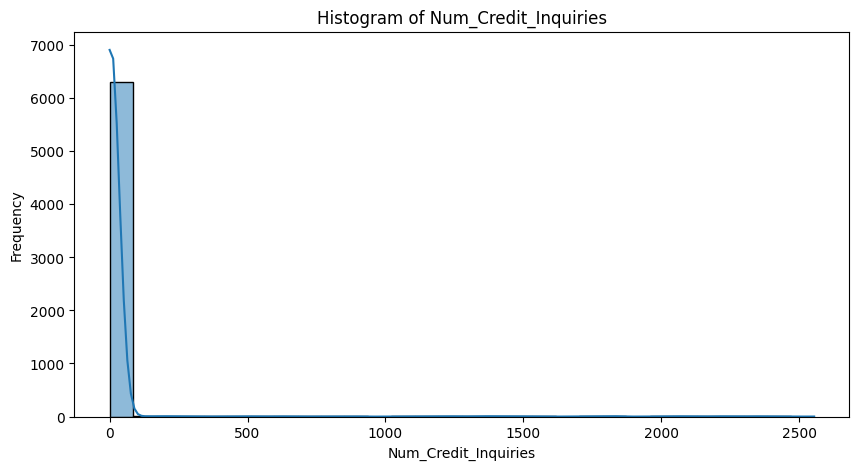

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(financials['Num_Credit_Inquiries'].dropna(), bins=30, kde=True)
plt.title('Histogram of Num_Credit_Inquiries')
plt.xlabel('Num_Credit_Inquiries')
plt.ylabel('Frequency')
plt.show()

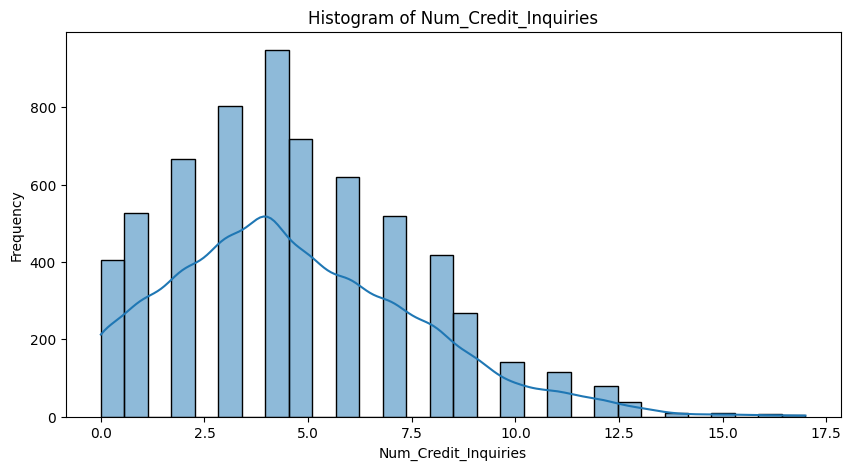

In [28]:
financials = financials[financials['Num_Credit_Inquiries'] <= 30]

plt.figure(figsize=(10, 5))
sns.histplot(financials['Num_Credit_Inquiries'].dropna(), bins=30, kde=True)
plt.title('Histogram of Num_Credit_Inquiries')
plt.xlabel('Num_Credit_Inquiries')
plt.ylabel('Frequency')
plt.show()

In [29]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Credit_Mix'].value_counts(dropna=False)

Credit_Mix
Good        2664
Standard    2199
_           1340
Bad           93
Name: count, dtype: int64

In [30]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Outstanding_Debt'].value_counts(dropna=False)

Outstanding_Debt
1130.29     2
611.96      2
630.24      2
82.6        2
1491.08     2
201.05      2
1453.63     2
469.43      2
563.84      2
935.74      2
462.11      2
503.23      2
101.29      2
227.12      2
765.97      2
157.62      2
1135.31     2
189.28      2
1123.0      2
1286.59     2
1362.09     2
1484.51     2
1132.46     2
1273.32     2
1344.45     2
1029.35     2
64.53       2
1253.52     2
1422.93     2
463.57      2
656.57      2
729.74      2
404.81      2
1072.42     2
687.87      2
64.65       2
759.86      2
1381.1      2
1454.68     2
139.77      2
562.34      2
1423.88     2
330.98      2
699.36      2
1434.18     2
604.77      2
342.3       2
832.55      2
466.13      2
557.78      2
590.29      2
441.46      2
129.15      2
176.43      2
298.5       2
579.47      2
100.3       2
795.69      2
854.72      2
177.03      2
327.22      2
1421.95     2
1075.37     2
1017.45     2
861.13      2
1413.55     2
768.69      2
6.41        2
198.06      2
248.84      2
467

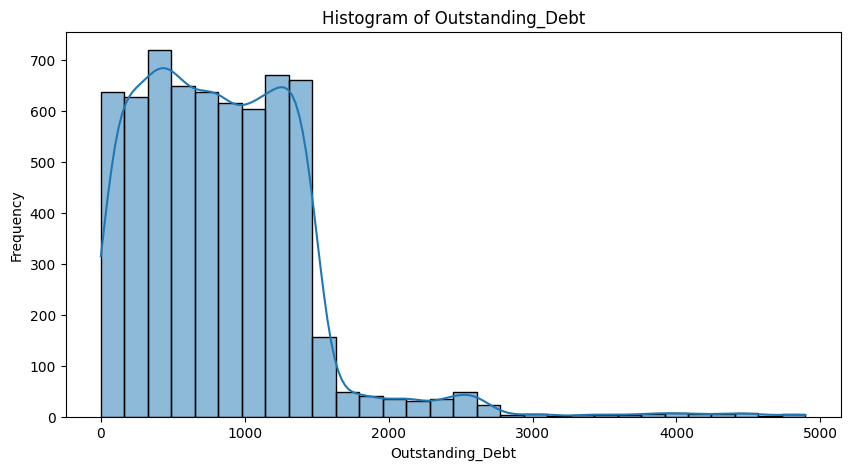

In [31]:
financials['Outstanding_Debt'] = pd.to_numeric(financials['Outstanding_Debt'].astype(str).str.replace('_', ''), errors='coerce')

plt.figure(figsize=(10, 5))
sns.histplot(financials['Outstanding_Debt'].dropna(), bins=30, kde=True)
plt.title('Histogram of Outstanding_Debt')
plt.xlabel('Outstanding_Debt')
plt.ylabel('Frequency')
plt.show()

In [32]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Credit_Utilization_Ratio'].value_counts(dropna=False)

Credit_Utilization_Ratio
26.524864    1
38.491857    1
30.816772    1
39.713934    1
26.256025    1
37.169635    1
34.471026    1
34.768804    1
34.843337    1
36.767676    1
41.660071    1
29.108222    1
38.380422    1
29.606152    1
41.947554    1
38.065103    1
37.143181    1
34.495658    1
30.877969    1
34.655182    1
24.142897    1
27.295364    1
31.584515    1
38.771783    1
41.213794    1
28.873269    1
33.474914    1
27.205701    1
39.655419    1
22.965565    1
41.910374    1
33.433097    1
38.524392    1
42.367963    1
32.401352    1
39.853305    1
23.457935    1
31.672504    1
39.101351    1
28.394498    1
34.192463    1
27.464273    1
34.271988    1
27.176601    1
25.128990    1
33.042293    1
43.458512    1
25.242781    1
33.221552    1
28.411323    1
36.476414    1
34.535877    1
33.427510    1
36.392328    1
36.085630    1
33.788430    1
31.778662    1
34.491134    1
38.065920    1
26.325793    1
33.152861    1
38.854724    1
37.033519    1
35.523326    1
40.181251    1


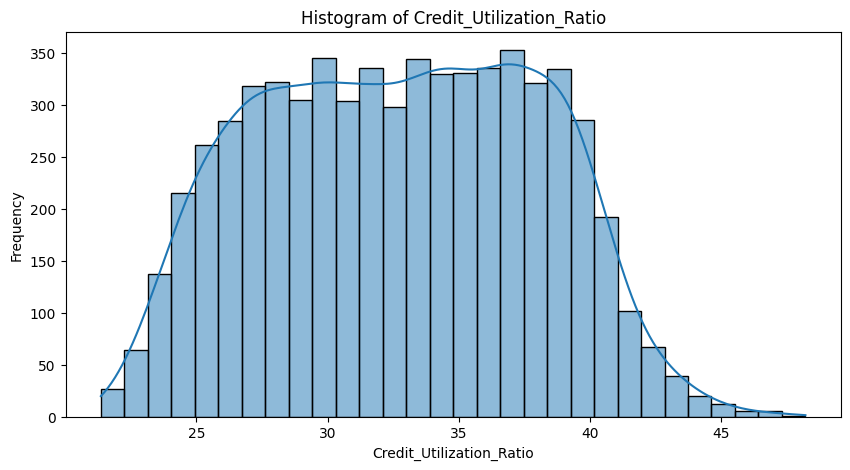

In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(financials['Credit_Utilization_Ratio'].dropna(), bins=30, kde=True)
plt.title('Histogram of Credit_Utilization_Ratio')
plt.xlabel('Credit_Utilization_Ratio')
plt.ylabel('Frequency')
plt.show()

In [34]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Credit_History_Age'].value_counts(dropna=False)

Credit_History_Age
19 Years and 9 Months     49
18 Years and 10 Months    45
18 Years and 5 Months     45
31 Years and 3 Months     44
19 Years and 5 Months     43
18 Years and 2 Months     42
16 Years and 0 Months     41
19 Years and 6 Months     41
18 Years and 4 Months     41
29 Years and 5 Months     40
16 Years and 9 Months     40
16 Years and 5 Months     40
18 Years and 0 Months     40
18 Years and 3 Months     40
16 Years and 10 Months    40
17 Years and 5 Months     39
22 Years and 11 Months    38
20 Years and 8 Months     38
18 Years and 11 Months    38
17 Years and 9 Months     38
33 Years and 5 Months     38
22 Years and 3 Months     38
18 Years and 6 Months     38
30 Years and 10 Months    38
15 Years and 9 Months     37
16 Years and 4 Months     37
23 Years and 5 Months     37
20 Years and 5 Months     37
17 Years and 10 Months    37
16 Years and 3 Months     37
27 Years and 11 Months    36
17 Years and 11 Months    36
19 Years and 11 Months    36
20 Years and 4 Months   

In [35]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Payment_of_Min_Amount'].value_counts(dropna=False)

Payment_of_Min_Amount
No     3657
Yes    1909
NM      730
Name: count, dtype: int64

In [36]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Total_EMI_per_month'].value_counts(dropna=False)



Total_EMI_per_month
0.000000        955
22409.000000      2
228.018084        1
32.747967         1
74.869250         1
1320.790134       1
93.834367         1
349.919748        1
298.196855        1
31.093901         1
83.573795         1
255.607521        1
85.886047         1
144.771246        1
230.798330        1
200.559365        1
48.482084         1
197.039943        1
36.822939         1
45.000319         1
30.118977         1
31.095873         1
35.104023         1
57.053182         1
16.245051         1
36.860440         1
53.515554         1
22.764457         1
56.123060         1
41.364817         1
102.284260        1
112.174744        1
42.742361         1
21.271029         1
69.432414         1
50.192752         1
77.096024         1
41.204378         1
17975.000000      1
113.493214        1
216.773941        1
150.821026        1
50.094992         1
14.887241         1
119.926490        1
119.088055        1
70.797236         1
186.357774        1
256.013595        1


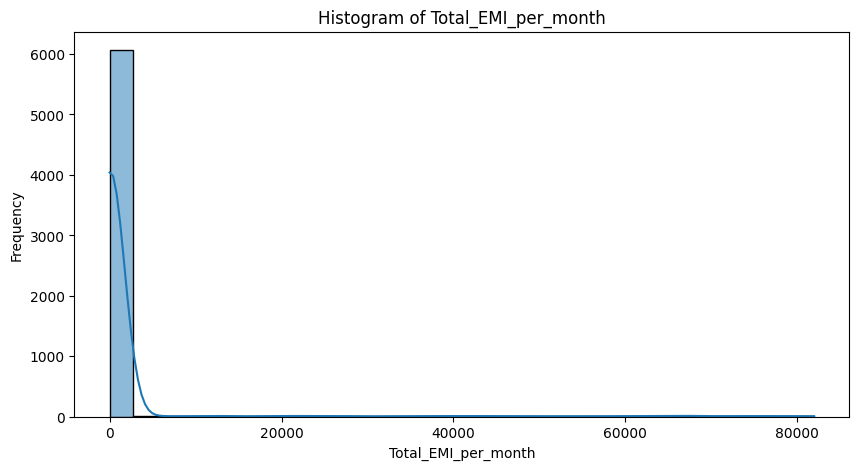

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(financials['Total_EMI_per_month'].dropna(), bins=30, kde=True)
plt.title('Histogram of Total_EMI_per_month')
plt.xlabel('Total_EMI_per_month')
plt.ylabel('Frequency')
plt.show()

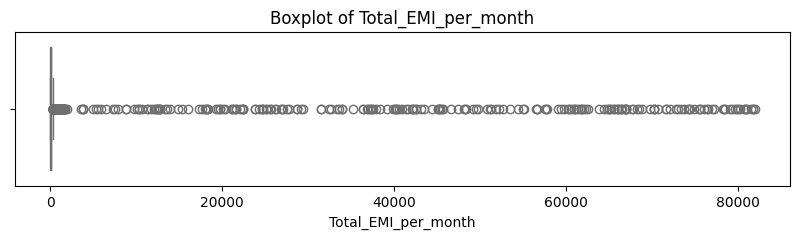

In [38]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=financials['Total_EMI_per_month'].dropna(), color='skyblue')
plt.title('Boxplot of Total_EMI_per_month')
plt.xlabel('Total_EMI_per_month')
plt.show()


In [39]:
Q1 = financials['Total_EMI_per_month'].quantile(0.25)
Q3 = financials['Total_EMI_per_month'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

# Cap values at upper_limit
financials['Total_EMI_per_month_capped'] = financials['Total_EMI_per_month'].apply(lambda x: upper_limit if x > upper_limit else x)


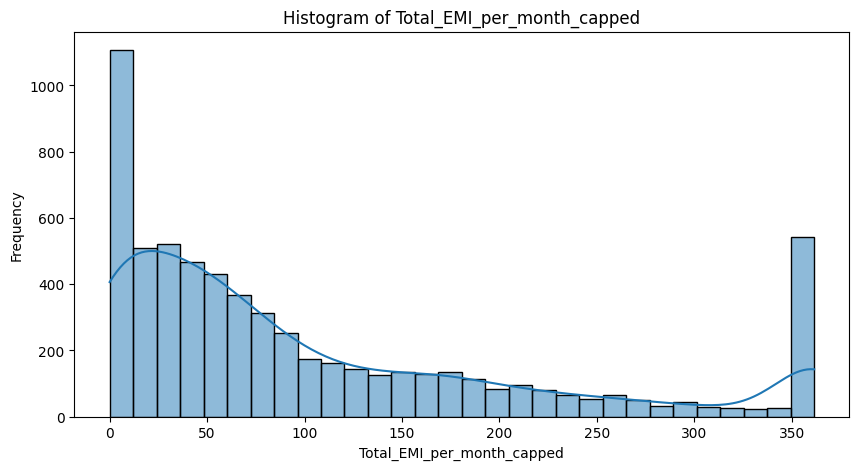

In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(financials['Total_EMI_per_month_capped'].dropna(), bins=30, kde=True)
plt.title('Histogram of Total_EMI_per_month_capped')
plt.xlabel('Total_EMI_per_month_capped')
plt.ylabel('Frequency')
plt.show()

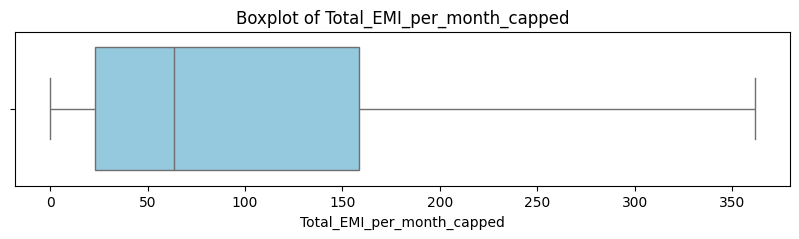

In [41]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=financials['Total_EMI_per_month_capped'].dropna(), color='skyblue')
plt.title('Boxplot of Total_EMI_per_month_capped')
plt.xlabel('Total_EMI_per_month_capped')
plt.show()


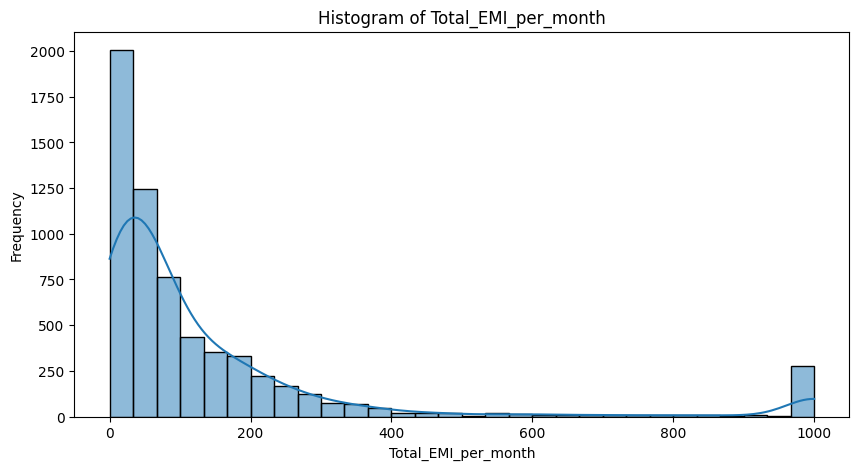

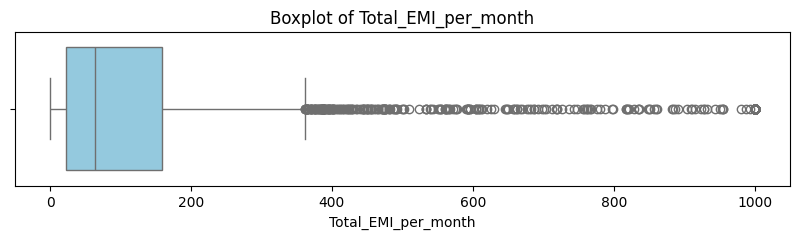

In [42]:
# Set a logical cap value (e.g., EMI shouldn't realistically exceed 1,000)
cap_value = 1000

# Cap values
financials['Total_EMI_per_month'] = financials['Total_EMI_per_month'].apply(
    lambda x: cap_value if x > cap_value else x
)

plt.figure(figsize=(10, 5))
sns.histplot(financials['Total_EMI_per_month'].dropna(), bins=30, kde=True)
plt.title('Histogram of Total_EMI_per_month')
plt.xlabel('Total_EMI_per_month')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 2))
sns.boxplot(x=financials['Total_EMI_per_month'].dropna(), color='skyblue')
plt.title('Boxplot of Total_EMI_per_month')
plt.xlabel('Total_EMI_per_month')
plt.show()


In [43]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Amount_invested_monthly'].value_counts(dropna=False)

Amount_invested_monthly
__10000__             280
0.0                     5
332.3337079767732       1
344.86177222949226      1
40.88652563284546       1
51.45842224457798       1
49.73072658342201       1
132.94592474041758      1
148.01159771677118      1
160.38895982092242      1
121.71924770343183      1
53.784940941445505      1
52.259237209390285      1
165.24132353940604      1
114.42736499990822      1
261.78050066834857      1
147.12785491327094      1
372.5215906261605       1
166.6014378943739       1
83.97569574837961       1
211.60555062088642      1
350.53058050295243      1
148.5042759499367       1
245.07429546625016      1
200.25840722756362      1
174.63780863714248      1
55.16030439979549       1
480.05621034517446      1
381.89399445938164      1
89.92505177503266       1
56.87564835604431       1
88.92109355205618       1
364.268135354966        1
110.36644649164684      1
37.57726184863831       1
364.6766651510254       1
1035.5889127308708      1
178.6194708754

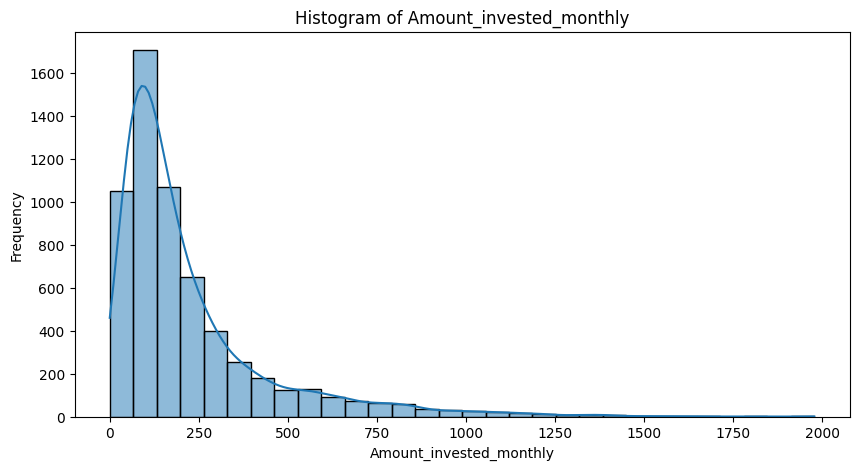

In [44]:
# Replace "__10000__" with NaN
financials['Amount_invested_monthly'] = financials['Amount_invested_monthly'].replace("__10000__", np.nan).astype(float)

# Plot histogram of Amount_invested_monthly (excluding NaN by default)
plt.figure(figsize=(10, 5))
sns.histplot(financials['Amount_invested_monthly'].dropna(), bins=30, kde=True)
plt.title('Histogram of Amount_invested_monthly')
plt.xlabel('Amount_invested_monthly')
plt.ylabel('Frequency')
plt.show()


In [45]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Payment_Behaviour'].value_counts(dropna=False)

Payment_Behaviour
Low_spent_Small_value_payments      1394
High_spent_Medium_value_payments    1211
High_spent_Large_value_payments      968
Low_spent_Medium_value_payments      836
High_spent_Small_value_payments      719
Low_spent_Large_value_payments       668
!@9#%8                               500
Name: count, dtype: int64

In [46]:
pd.set_option('display.max_rows', None)  # Show all rows
financials['Monthly_Balance'].value_counts(dropna=False)

Monthly_Balance
485.889708            1
276.167442            1
201.457928            1
451.453308            1
310.815557            1
336.486528            1
297.027996            1
711.965287            1
726.414957            1
1029.265809           1
862.89637             1
370.875527            1
328.57245             1
734.214749            1
678.780986            1
602.043576            1
610.59538             1
291.485605            1
285.807895            1
444.070419            1
467.237867            1
552.523428            1
317.67785             1
484.770298            1
678.279336            1
250.701053            1
381.381292            1
340.857637            1
560.663311            1
300.14217             1
856.143188            1
273.082862            1
201.433507            1
911.116675            1
389.571828            1
1090.549454           1
207.30214             1
131.627146            1
605.65667             1
341.867983            1
393.673696            1


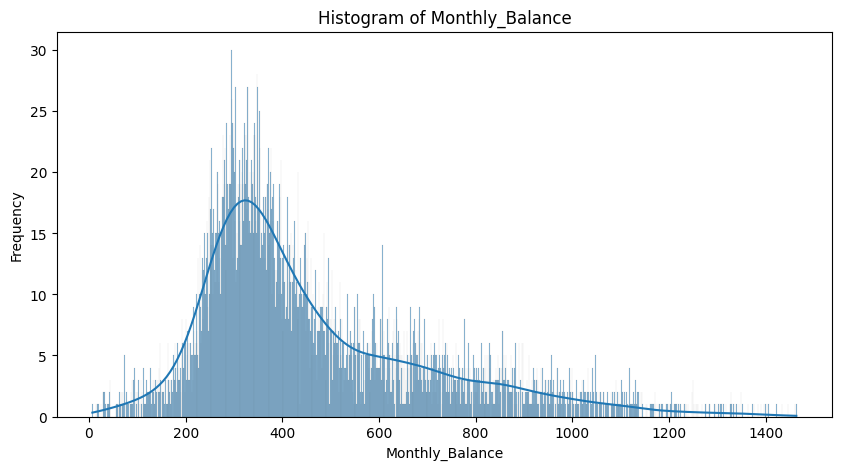

In [47]:
# Plot histogram 
plt.figure(figsize=(10, 5))
sns.histplot(financials['Monthly_Balance'].dropna(), bins=30, kde=True)
plt.title('Histogram of Monthly_Balance')
plt.xlabel('Monthly_Balance')
plt.ylabel('Frequency')
plt.show()

### Summary Statistics for Numerical Columns 

In [48]:
for name, df in [("LMS", lms), ("Financials", financials), ("Attributes", attributes), ("Clickstream", clickstream)]:
    print(f"\n--- Summary stats for {name} ---")
    print(df.describe(include=[np.number]))



--- Summary stats for LMS ---
         tenure  installment_num  loan_amt        due_amt       paid_amt  \
count  104288.0    104288.000000  104288.0  104288.000000  104288.000000   
mean       10.0         4.471684   10000.0     885.183338     704.405109   
std         0.0         3.116241       0.0     318.802086     492.453588   
min        10.0         0.000000   10000.0       0.000000       0.000000   
25%        10.0         2.000000   10000.0    1000.000000       0.000000   
50%        10.0         4.000000   10000.0    1000.000000    1000.000000   
75%        10.0         7.000000   10000.0    1000.000000    1000.000000   
max        10.0        10.000000   10000.0    1000.000000    4000.000000   

         overdue_amt        balance  
count  104288.000000  104288.000000  
mean      747.957579    6276.273397  
std      1828.231563    2960.529662  
min         0.000000       0.000000  
25%         0.000000    4000.000000  
50%         0.000000    7000.000000  
75%         0.0000

ValueError: No objects to concatenate

### Inspect the Silver CSV files created for data understanding/ cleaning/ processing 

In [9]:
filepath = "datamart/silver/merged/silver_merged_2024_12_01.parquet"
silver_df = pd.read_parquet(filepath)
pd.set_option('display.max_columns', None)
silver_df.tail(20) 

,Customer_ID,loan_id,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd,installment_coverage,Name,SSN,Occupation,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Num_of_Delayed_Payment,Credit_History_Months,Loan_Not_Specified,Loan_debt_consolidation_loan,Loan_personal_loan,Loan_payday_loan,Loan_mortgage_loan,Loan_credit_builder_loan,Loan_auto_loan,Loan_home_equity_loan,Loan_student_loan,DTI,num_active_loans,credit_history_bucket,credit_inquiries_bucket,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
5511,CUS_0xf3c,CUS_0xf3c_2024_09_01,2024-09-01,10,3,10000.0,1000.0,1000.0,0.0,7000.0,2024-12-01,3,0,None,0,1.0,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5512,CUS_0xf42,CUS_0xf42_2024_04_01,2024-04-01,10,8,10000.0,1000.0,0.0,4000.0,6000.0,2024-12-01,8,4,2024-08-01,122,0.0,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,185.0,89.0,162.0,-24.0,149.0,-29.0,120.0,93.0,105.0,129.0,81.0,124.0,57.0,-124.0,176.0,92.0,189.0,48.0,-39.0,193.0
5513,CUS_0xf43,CUS_0xf43_2024_11_01,2024-11-01,10,1,10000.0,1000.0,1000.0,0.0,9000.0,2024-12-01,1,0,None,0,1.0,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5514,CUS_0xf4b,CUS_0xf4b_2024_05_01,2024-05-01,10,7,10000.0,1000.0,0.0,4000.0,7000.0,2024-12-01,7,4,2024-08-01,122,0.0,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,65.0,138.0,-68.0,38.0,41.0,193.0,120.0,69.0,185.0,-93.0,245.0,17.0,127.0,205.0,-59.0,153.0,168.0,109.0,115.0,284.0
5515,CUS_0xf55,CUS_0xf55_2024_12_01,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0,NaN,Tarmo Virkip,025-54-8593,entrepreneur,39.0,78443.476562,6358.956543,7.0,5.0,23.0,4.0,39.0,6.37,6.0,Bad,1527.770020,24.704428,NM,177.387558,528.746887,Low_spent_Medium_value_payments,209.761200,19.0,190.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.027896,4.0,Long,Medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5516,CUS_0xf64,CUS_0xf64_2024_04_01,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0,1.0,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,161.0,-24.0,-115.0,268.0,66.0,147.0,79.0,37.0,50.0,28.0,160.0,138.0,104.0,118.0,24.0,204.0,123.0,277.0,-82.0,70.0
5517,CUS_0xf6c,CUS_0xf6c_2024_02_01,2024-02-01,10,10,10000.0,1000.0,1000.0,0.0,0.0,2024-12-01,10,0,None,0,1.0,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,-19.0,98.0,147.0,69.0,-74.0,-156.0,68.0,93.0,44.0,257.0,204.0,163.0,129.0,65.0,-78.0,72.0,281.0,130.0,-1.0,-5.0
5518,CUS_0xf70,CUS_0xf70_2024_06_01,2024-06-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-12-01,6,0,None,0,1.0,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,69.0,-39.0,106.0,186.0,63.0,154.0,241.0,159.0,-34.0,449.0,49.0,189.0,125.0,36.0,32.0,67.0,-112.0,5.0,-18.0,-99.0
5519,CUS_0xf7d,CUS_0xf7d_2024_05_01,

In [10]:
pd.set_option('display.max_rows', None)  # Show all rows
silver_df['credit_inquiries_bucket'].value_counts(dropna=False)

credit_inquiries_bucket
None      5025
Low        228
Medium     189
High        89
Name: count, dtype: int64

Date still appears as object Dtype because 
- PySpark stores dates as dates.
- Parquet format preserves the schema, but when Pandas reads Parquet, sometimes it still treats dates as objects.
- Pandas needs an explicit conversion after reading.

Some features type-casted into Integer still appears as float64 Dtype because 
- For a column like Age, which contains nulls, Pandas automatically upcasts it to float64, because traditional NumPy integer types (int32, int64) do not support nulls (NaN). On the other hand, column like tenure is preserved as int32 because it has no null values.

In [45]:
pd.set_option('display.max_rows', None)  # Show all rows
silver_df['Credit_History_Months'].value_counts(dropna=False)

Credit_History_Months
NaN      5016
196.0       6
176.0       6
246.0       6
213.0       6
225.0       6
190.0       6
70.0        5
237.0       5
242.0       5
344.0       5
280.0       5
232.0       4
326.0       4
244.0       4
144.0       4
291.0       4
148.0       4
375.0       4
219.0       4
195.0       4
248.0       4
285.0       4
230.0       4
201.0       4
227.0       4
365.0       4
389.0       4
119.0       4
366.0       4
114.0       4
159.0       4
222.0       4
214.0       4
204.0       4
226.0       3
314.0       3
189.0       3
346.0       3
80.0        3
330.0       3
238.0       3
221.0       3
92.0        3
304.0       3
75.0        3
318.0       3
233.0       3
267.0       3
275.0       3
192.0       3
250.0       3
362.0       3
316.0       3
279.0       3
209.0       3
251.0       3
172.0       3
147.0       3
146.0       3
351.0       3
243.0       3
398.0       3
220.0       3
287.0       3
173.0       3
234.0       3
269.0       3
216.0       3
294.0       

In [14]:
silver_df.columns

Index(['Customer_ID', 'loan_id', 'loan_start_date', 'tenure',
       'installment_num', 'loan_amt', 'due_amt', 'paid_amt', 'overdue_amt',
       'balance', 'snapshot_date', 'mob', 'installments_missed',
       'first_missed_date', 'dpd', 'installment_coverage', 'Name', 'SSN',
       'Occupation', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
       'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Num_of_Delayed_Payment', 'Credit_History_Months', 'Loan_Not_Specified',
       'Loan_debt_consolidation_loan', 'Loan_personal_loan',
       'Loan_payday_loan', 'Loan_mortgage_loan', 'Loan_credit_builder_loan',
       'Loan_auto_loan', 'Loan_home_equity_loan', 'Loan_student_loan', 'DTI',
  

In [13]:
silver_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5531 entries, 0 to 5530
Data columns (total 72 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer_ID                   5531 non-null   object 
 1   loan_id                       5531 non-null   object 
 2   loan_start_date               5531 non-null   object 
 3   tenure                        5531 non-null   int32  
 4   installment_num               5531 non-null   int32  
 5   loan_amt                      5531 non-null   float32
 6   due_amt                       5531 non-null   float32
 7   paid_amt                      5531 non-null   float32
 8   overdue_amt                   5531 non-null   float32
 9   balance                       5531 non-null   float32
 10  snapshot_date                 5531 non-null   object 
 11  mob                           5531 non-null   int32  
 12  installments_missed           5531 non-null   int32  
 13  fir

### Check for Duplicates

In [12]:
# Check how many duplicates exist
duplicate_rows = silver_df[silver_df.duplicated(subset=["Customer_ID"], keep=False)]
print(f"Number of duplicates: {len(duplicate_rows)}")

# View the duplicate rows
display(duplicate_rows)



Number of duplicates: 0


,Customer_ID,loan_id,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd,installment_coverage,Name,SSN,Occupation,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Num_of_Delayed_Payment,Credit_History_Months,Loan_Not_Specified,Loan_debt_consolidation_loan,Loan_personal_loan,Loan_payday_loan,Loan_mortgage_loan,Loan_credit_builder_loan,Loan_auto_loan,Loan_home_equity_loan,Loan_student_loan,DTI,num_active_loans,credit_history_bucket,credit_inquiries_bucket,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20


### Check for Missing Values
- Note: both NaN and None are treated as missing values

In [11]:
missing_counts = silver_df.isna().sum()
missing_percentage = (missing_counts / len(silver_df)) * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percentage': missing_percentage
})

print(missing_summary)

                              missing_count  missing_percentage
Customer_ID                               0            0.000000
loan_id                                   0            0.000000
loan_start_date                           0            0.000000
tenure                                    0            0.000000
installment_num                           0            0.000000
loan_amt                                  0            0.000000
due_amt                                   0            0.000000
paid_amt                                  0            0.000000
overdue_amt                               0            0.000000
balance                                   0            0.000000
snapshot_date                             0            0.000000
mob                                       0            0.000000
installments_missed                       0            0.000000
first_missed_date                      4319           78.087145
dpd                                     

### Inspect Gold Feature and Label Stores (after editing data pipeline)

In [10]:
filepath = "datamart/gold/feature_store"
feature_store_df = pd.read_parquet(filepath)

pd.set_option('display.max_columns', None)
feature_store_df.head(50) 

,Customer_ID,Name,SSN,snapshot_date,Age,occupation_developer,occupation_scientist,occupation_engineer,occupation_teacher,occupation_manager,occupation_enterpreneur,occupation_mechanic,occupation_musician,occupation_architect,occupation_writer,occupation_accountant,occupation_journalist,occupation_lawyer,occupation_doctor,occupation_media_manager,occupation_unknown,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Credit_Mix_None,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_Yes,Payment_of_Min_Amount_No,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_None,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_None,Loan_Not_Specified,Loan_debt_consolidation_loan,Loan_personal_loan,Loan_payday_loan,Loan_mortgage_loan,Loan_credit_builder_loan,Loan_auto_loan,Loan_home_equity_loan,Loan_student_loan,disposable_income,DTI,num_active_loans,credit_history_bucket_Short,credit_history_bucket_Medium,credit_history_bucket_Long,credit_history_bucket_None,credit_inquiries_bucket_Low,credit_inquiries_bucket_Medium,credit_inquiries_bucket_High,credit_inquiries_bucket_None,avg_fe_1,avg_fe_2,avg_fe_3,avg_fe_4,avg_fe_5,avg_fe_6,avg_fe_7,avg_fe_8,avg_fe_9,avg_fe_10,avg_fe_11,avg_fe_12,avg_fe_13,avg_fe_14,avg_fe_15,avg_fe_16,avg_fe_17,avg_fe_18,avg_fe_19,avg_fe_20
0,CUS_0x1b66,Valetkevitchj,444-26-5685,2023-01-01,34.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,5.053858e+04,4054.548340,6.0,7.0,9.0,4.0,17,9.090000,1205.130005,23.560961,164.807465,256.246460,254.400909,21.0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,1,0,1,0,0,3889.740967,0.040648,4,0,0,1,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CUS_0x2abc,Karenf,102-67-0486,2023-01-01,19.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1.386483e+04,949.402893,3.0,3.0,9.0,1.0,10,14.650000,554.130005,31.098274,10.420393,59.225185,295.294708,14.0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,938.982483,0.010976,1,0,0,1,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CUS_0x75e,Koltrowitzq,606-90-0153,2023-01-01,38.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,7.719052e+04,6470.543457,4.0,7.0,5.0,7.0,13,12.300000,75.940002,26.465611,253.049164,NaN,587.592529,12.0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,0,1,1,0,6217.494141,0.039108,4,0,0,1,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CUS_0x7910,Raymondu,995-60-4305,2023-01-01,35.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.186458e+05,9525.400391,2.0,5.0,5.0,3.0,2,5.560000,1480.890015,35.547718,861.917175,202.605072,840.542358,10.0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,8663.483398,0.090486,3,0,0,1,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CUS_0x79ac,Jean-Baptistea,833-71-1983,2023-01-01,40.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,4.664586e+04,4056.155029,4.0,3.0,5.0,2.0,10,10.890000,1157.310059,36.326778,61.795319,392.293030,241.527161,10.0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,3994.359619,0.015235,1,0,0,1,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CUS_0x1630,Laurence Fletchery,638-52-4307,2023-01-01,35.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1.770615e+07,6943.133301,4.0,6.0,10.0,6.0,9,16.549999,377.049988,32.086624,340.287720,396.248169,237.777435,10.0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1,1,1,0,0,0,0,0,1,6602.845703,0.049011,3,0,0,1,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CUS_0x3231,Jan Strupczewskid,408-03-6761,2023-01-01,44.0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [11]:
filepath = "datamart/gold/label_store"
label_store_df = pd.read_parquet(filepath)

pd.set_option('display.max_columns', None)
label_store_df.head(50) 

,Customer_ID,loan_id,label,snapshot_date,label_def
0,CUS_0x100b,CUS_0x100b_2024_03_01,0,2024-09-01,30dpd_6mob
1,CUS_0x1096,CUS_0x1096_2024_03_01,1,2024-09-01,30dpd_6mob
2,CUS_0x111c,CUS_0x111c_2024_03_01,1,2024-09-01,30dpd_6mob
3,CUS_0x112d,CUS_0x112d_2024_03_01,1,2024-09-01,30dpd_6mob
4,CUS_0x1204,CUS_0x1204_2024_03_01,1,2024-09-01,30dpd_6mob
5,CUS_0x12af,CUS_0x12af_2024_03_01,0,2024-09-01,30dpd_6mob
6,CUS_0x12cb,CUS_0x12cb_2024_03_01,1,2024-09-01,30dpd_6mob
7,CUS_0x12fc,CUS_0x12fc_2024_03_01,0,2024-09-01,30dpd_6mob
8,CUS_0x144c,CUS_0x144c_2024_03_01,0,2024-09-01,30dpd_6mob
9,CUS_0x1546,CUS_0x1546_2024_03_01,0,2024-09-01,30dpd_6mob


In [12]:
filepath = "datamart/gold/combined_store"
combined_store_df = pd.read_parquet(filepath)

pd.set_option('display.max_columns', None)
combined_store_df.head(50) 

,Customer_ID,Name,SSN,snapshot_date,Age,occupation_developer,occupation_scientist,occupation_engineer,occupation_teacher,occupation_manager,occupation_enterpreneur,occupation_mechanic,occupation_musician,occupation_architect,occupation_writer,occupation_accountant,occupation_journalist,occupation_lawyer,occupation_doctor,occupation_media_manager,occupation_unknown,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Credit_Mix_None,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_Yes,Payment_of_Min_Amount_No,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_None,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_None,Loan_Not_Specified,Loan_debt_consolidation_loan,Loan_personal_loan,Loan_payday_loan,Loan_mortgage_loan,Loan_credit_builder_loan,Loan_auto_loan,Loan_home_equity_loan,Loan_student_loan,disposable_income,DTI,num_active_loans,credit_history_bucket_Short,credit_history_bucket_Medium,credit_history_bucket_Long,credit_history_bucket_None,credit_inquiries_bucket_Low,credit_inquiries_bucket_Medium,credit_inquiries_bucket_High,credit_inquiries_bucket_None,avg_fe_1,avg_fe_2,avg_fe_3,avg_fe_4,avg_fe_5,avg_fe_6,avg_fe_7,avg_fe_8,avg_fe_9,avg_fe_10,avg_fe_11,avg_fe_12,avg_fe_13,avg_fe_14,avg_fe_15,avg_fe_16,avg_fe_17,avg_fe_18,avg_fe_19,avg_fe_20,label
0,CUS_0x1b66,Valetkevitchj,444-26-5685,2023-01-01,34.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,5.053858e+04,4054.548340,6.0,7.0,9.0,4.0,17,9.090000,1205.130005,23.560961,164.807465,256.246460,254.400909,21.0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,1,0,1,0,0,3889.740967,0.040648,4,0,0,1,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,CUS_0x2abc,Karenf,102-67-0486,2023-01-01,19.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1.386483e+04,949.402893,3.0,3.0,9.0,1.0,10,14.650000,554.130005,31.098274,10.420393,59.225185,295.294708,14.0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,938.982483,0.010976,1,0,0,1,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,CUS_0x75e,Koltrowitzq,606-90-0153,2023-01-01,38.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,7.719052e+04,6470.543457,4.0,7.0,5.0,7.0,13,12.300000,75.940002,26.465611,253.049164,NaN,587.592529,12.0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,0,1,1,0,6217.494141,0.039108,4,0,0,1,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,CUS_0x7910,Raymondu,995-60-4305,2023-01-01,35.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.186458e+05,9525.400391,2.0,5.0,5.0,3.0,2,5.560000,1480.890015,35.547718,861.917175,202.605072,840.542358,10.0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,8663.483398,0.090486,3,0,0,1,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CUS_0x79ac,Jean-Baptistea,833-71-1983,2023-01-01,40.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,4.664586e+04,4056.155029,4.0,3.0,5.0,2.0,10,10.890000,1157.310059,36.326778,61.795319,392.293030,241.527161,10.0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,3994.359619,0.015235,1,0,0,1,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,CUS_0x1630,Laurence Fletchery,638-52-4307,2023-01-01,35.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1.770615e+07,6943.133301,4.0,6.0,10.0,6.0,9,16.549999,377.049988,32.086624,340.287720,396.248169,237.777435,10.0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1,1,1,0,0,0,0,0,1,6602.845703,0.049011,3,0,0,1,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
6,CUS_0x3231,Jan Strupczewskid,408-03-6761,2023-01-01,44.0,0,0,0,0,

### Model Inference 

In [10]:
filepath = "datamart/gold/model_predictions"
model_predictions_df = pd.read_parquet(filepath)

pd.set_option('display.max_columns', None)
model_predictions_df.head(5) 

,Customer_ID,snapshot_date,model_name,model_predictions
0,CUS_0x13ef,2023-01-01,XGB_model_2024_06_01.pkl,0.076619
1,CUS_0x3e9c,2023-01-01,XGB_model_2024_06_01.pkl,0.068687
2,CUS_0x4c29,2023-01-01,XGB_model_2024_06_01.pkl,0.116544
3,CUS_0x64b8,2023-01-01,XGB_model_2024_06_01.pkl,0.133152
4,CUS_0x929a,2023-01-01,XGB_model_2024_06_01.pkl,0.072440
